Connected to Python 3.13.9

Team 5: Harshith, Muhannad, Ebrima
Topic: Analysis of the Crime Rate Incidents in Los Angeles: Focus on 2024 Data
Github Repo Link: https://github.com/Ebrima170/G5_Data-Mining-Project-Repo

1. CONTEXT AND DATASET DESCRIPTION
This project uses a dataset from LPAD on the crime rates in Los Angeles.
The original data set contains several years, but for the purpose of this project, we are focusing only on the data for 2024.
Description of the variables can be found on the word document.

Columns in the dataset:
['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
'LON']'''

============================================================
 TEAM 5 — Final Python Script
Ebrima, Harshith, Muhannad
 Data Mining Project
============================================================

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import chi2_contingency, kendalltau

============================================================
 1. LOAD DATA
============================================================

In [ ]:
data = pd.read_excel(
    'Crime_Data_LA_2024.xlsx'
)
print("\nRaw data loaded:")
print(data.head())
print(data.info())


#============================================================
# 2. STANDARDIZE COLUMN NAMES ONCE
#============================================================
data.columns = (
    data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
)

#============================================================
# 3. DROP COLUMNS WITH TOO MANY MISSING VALUES
#============================================================
drop_cols = [
    'mocodes','cross street','crm cd 1','crm cd 2',
    'crm cd 3','crm cd 4','weapon used cd','weapon desc'
]
existing_drop_cols = [c for c in drop_cols if c in data.columns]
data = data.drop(columns=existing_drop_cols)


#============================================================
# 4. CLEAN STRING COLUMNS PROPERLY
#============================================================
string_placeholders = ["", " ", "nan", "na", "n/a", "none", "unknown", "null"]

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].astype(str).str.strip()
        data[col] = data[col].replace(string_placeholders, np.nan)


#============================================================
# 5. FIX DATE COLUMNS
#============================================================
date_cols = ["date rptd", "date occ"]
for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

#============================================================
# 6. FIX NUMERIC COLUMNS
#============================================================
numeric_cols = ["dr_no", "rpt_dist_no", "vict age", "lat", "lon"]

for col in numeric_cols:
    if col in data.columns:
        data[col] = (
            data[col]
            .astype(str)
            .str.replace(",", "", regex=False)
        )
        data[col] = pd.to_numeric(data[col], errors="coerce")


#============================================================
# 7. CLEAN VICTIM SEX (ONLY M/F ALLOWED)
#============================================================
if "vict_sex" in data.columns:
    data["vict_sex"] = data["vict_sex"].str.upper()
    data["vict_sex"] = data["vict_sex"].where(
        data["vict_sex"].isin(["M","F"]), np.nan
    )


#============================================================
# 8. FIX VICTIM AGE (REMOVE INVALID VALUES)
#============================================================
data["vict_age"] = pd.to_numeric(data["vict_age"], errors="coerce")
data.loc[(data["vict_age"] <= 0) | (data["vict_age"] > 110), "vict_age"] = np.nan


#============================================================
# 9. DROP ROWS MISSING KEY NUMERIC VARIABLES
#============================================================
data = data.dropna(subset=["lat", "lon", "vict_age"])

print("\nDataset AFTER CLEANING:")
print(data.info())
print(data.head())


#============================================================
# 10. IDENTIFY VARIABLE TYPES
#============================================================
numeric_vars = ["dr_no", "rpt_dist_no", "vict_age", "lat", "lon"]
categorical_vars = ["time_occ", "vict_sex", "premis_cd"]
datetime_vars = ["date_rptd", "date_occ"]


Raw data loaded:
                                               DR_NO  \
0  Division of Records case number (unique crime ...   
1                                          240913563   
2                                          240412063   
3                                          240317069   
4                                          241708596   

                                    Date Rptd  \
0  Date the crime was reported to the police.   
1                         2024-12-10 00:00:00   
2                         2024-12-11 00:00:00   
3                         2024-12-16 00:00:00   
4                         2024-04-20 00:00:00   

                            DATE OCC  \
0  Date the crime actually occurred.   
1                2020-10-30 00:00:00   
2                2020-11-11 00:00:00   
3                2020-04-16 00:00:00   
4                2020-03-02 00:00:00   

                                           TIME OCC  \
0  Time of occurrence (in military time, 0000-2359)   

============================================================
 11. SAFE EDA PLOTTING
============================================================

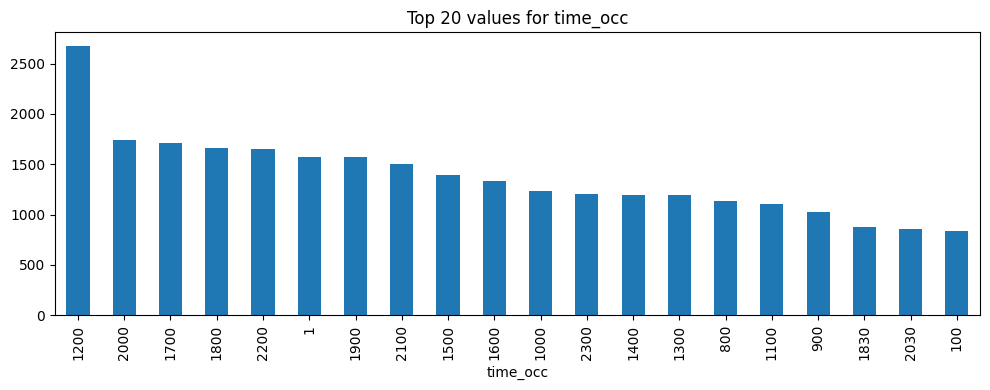

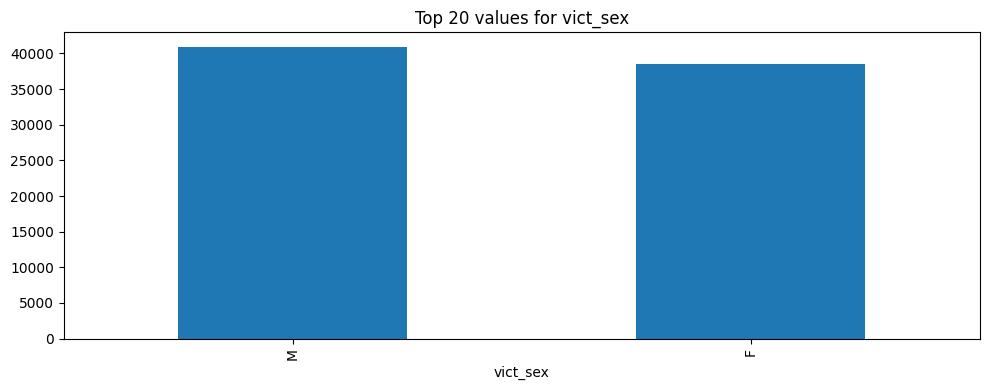

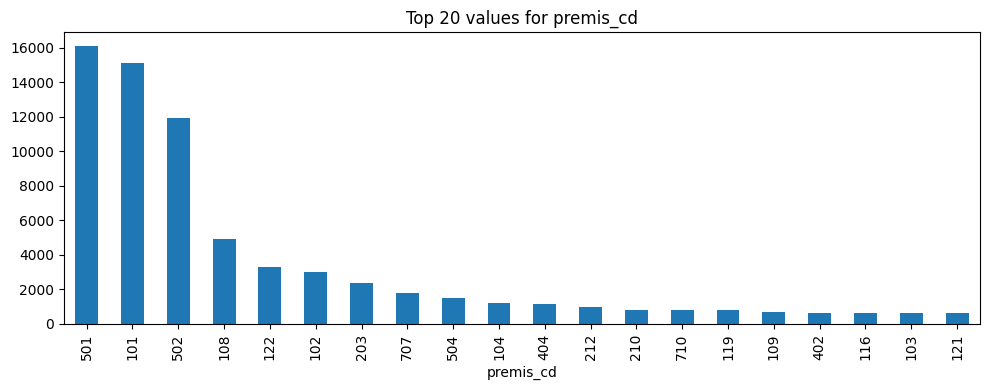

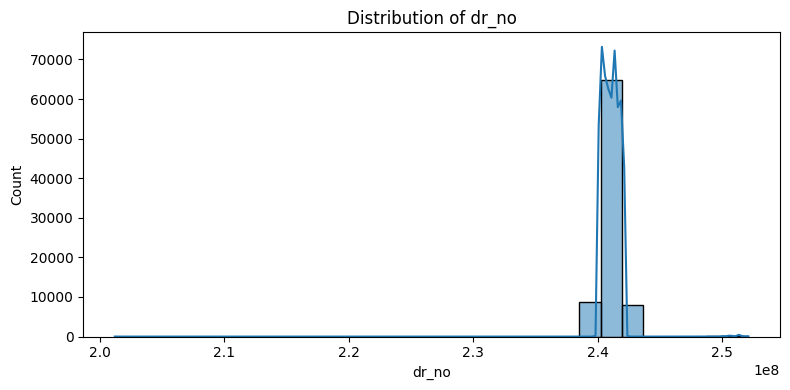

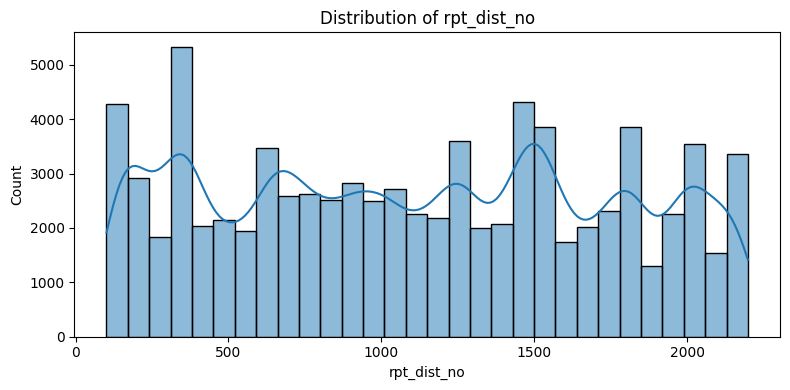

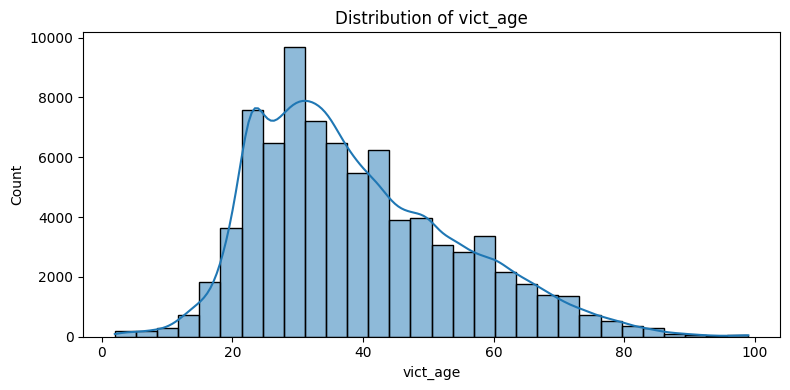

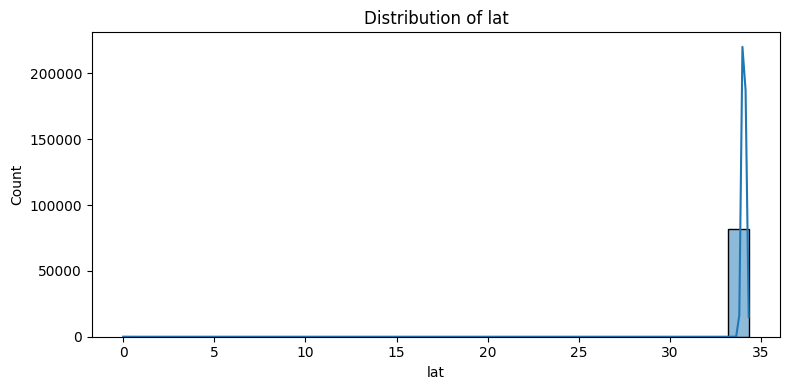

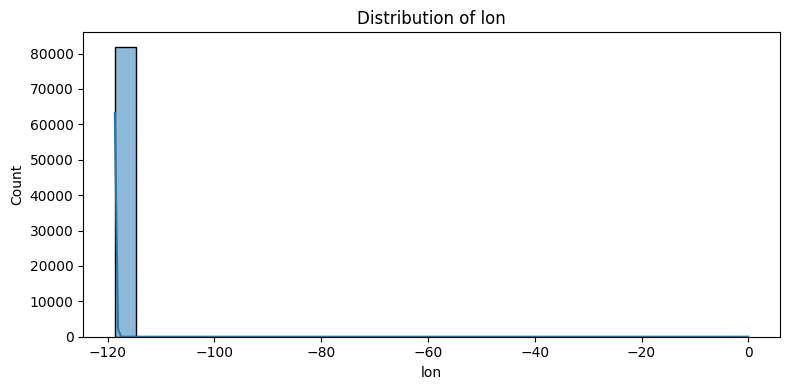

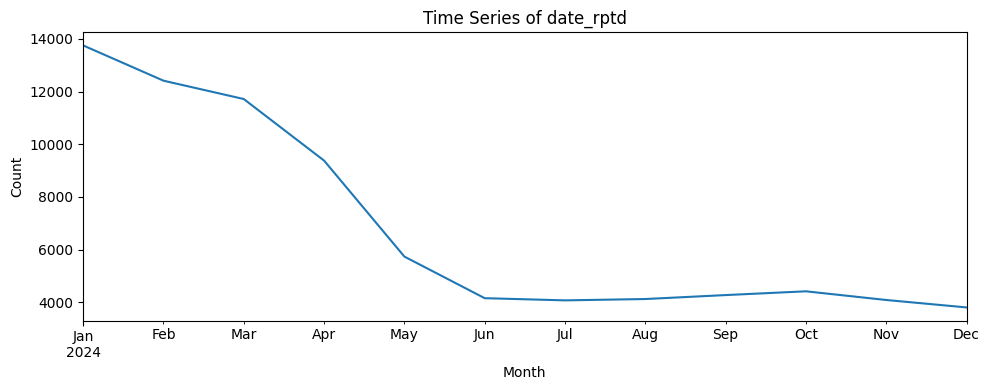

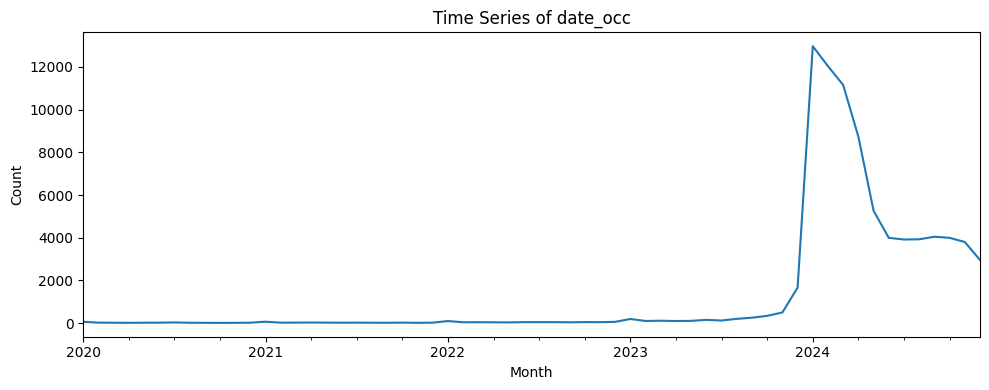

In [ ]:
for col in categorical_vars:
    if col in data.columns:
        plt.figure(figsize=(10, 4))
        data[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"Top 20 values for {col}")
        plt.tight_layout()
        plt.show()

for col in numeric_vars:
    if col in data.columns and not data[col].dropna().empty:
        plt.figure(figsize=(8, 4))
        sns.histplot(data[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()

for col in datetime_vars:
    if col in data.columns and not data[col].dropna().empty:
        # Ensure datetime
        data[col] = pd.to_datetime(data[col], errors="coerce")
        ts = data.dropna(subset=[col]).set_index(col)
        if ts.empty:
            print(f"Skipping {col} — no valid datetime entries.")
            continue
        # Resample and plot
        plt.figure(figsize=(10, 4))
        ts.resample("ME").size().plot()
        plt.title(f"Time Series of {col}")
        plt.xlabel("Month")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()



#============================================================
#Harshith's Question
# 15. SMART QUESTION 1 — CRIME TRENDS BY MONTH
#============================================================

3: Which crime types showed the sharpest increases or decreases in 2024?

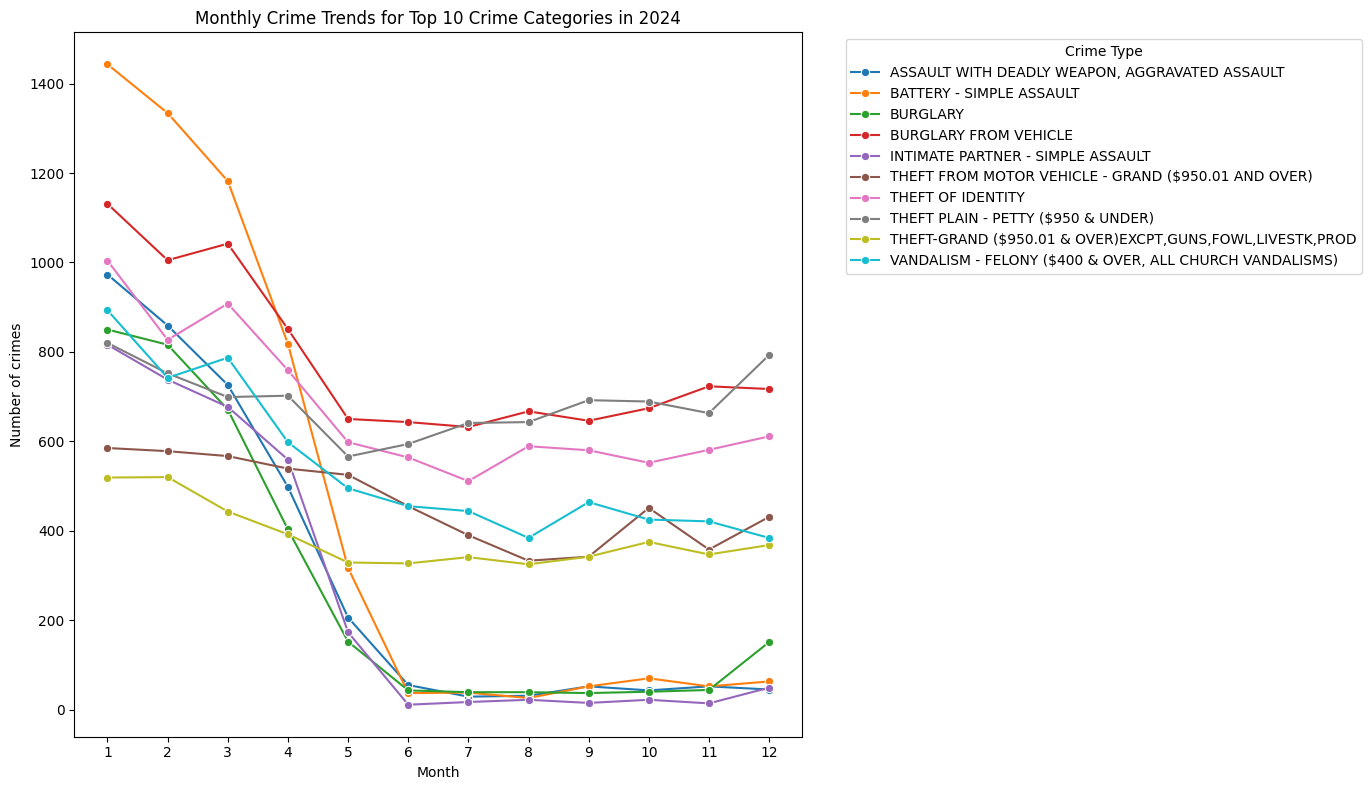

Top 10 rising crime types (change from start to end of year):
crm_cd_desc
PICKPOCKET                                              12.0
DISHONEST EMPLOYEE - GRAND THEFT                         1.0
DRIVING WITHOUT OWNER CONSENT (DWOC)                     1.0
THEFT, COIN MACHINE - PETTY ($950 & UNDER)               0.0
DRUNK ROLL - ATTEMPT                                     0.0
DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER     0.0
CONSPIRACY                                               0.0
DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01     0.0
PIMPING                                                  0.0
DISHONEST EMPLOYEE - PETTY THEFT                         0.0
Name: trend, dtype: float64

Top 10 declining crime types (change from start to end of year):
crm_cd_desc
BATTERY - SIMPLE ASSAULT                                  -1380.0
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT             -928.0
INTIMATE PARTNER - SIMPLE ASSAULT                          -767.0
BURGLARY    

In [ ]:
data['date_occ'] = pd.to_datetime(data['date_occ'], errors='coerce')
data = data[data['date_occ'].notna()].copy()
data['month'] = data['date_occ'].dt.month

crime_monthly = (
    data.groupby(['crm_cd_desc', 'month'])
        .size()
        .reset_index(name='count')
)

top_crimes = (
    data['crm_cd_desc']
        .value_counts()
        .head(10)
        .index
)

crime_monthly_top = crime_monthly[crime_monthly['crm_cd_desc'].isin(top_crimes)]
filtered_monthly = crime_monthly[
    crime_monthly['crm_cd_desc'].isin(top_crimes)
]

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=filtered_monthly,
    x='month',
    y='count',
    hue='crm_cd_desc',
    marker='o'
)
plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Number of crimes')
plt.title('Monthly Crime Trends for Top 10 Crime Categories in 2024')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

trend_pivot = crime_monthly.pivot(index='crm_cd_desc', columns='month', values='count').fillna(0)

if 1 in trend_pivot.columns and 12 in trend_pivot.columns:
    trend_pivot['trend'] = trend_pivot[12] - trend_pivot[1]
else:
    first_col = trend_pivot.columns.min()
    last_col = trend_pivot.columns.max()
    trend_pivot['trend'] = trend_pivot[last_col] - trend_pivot[first_col]

rising = trend_pivot.sort_values('trend', ascending=False).head(10)
falling = trend_pivot.sort_values('trend', ascending=True).head(10)

print("Top 10 rising crime types (change from start to end of year):")
print(rising['trend'])

print("\nTop 10 declining crime types (change from start to end of year):")
print(falling['trend'])
#=============

print(data.head())
print(data.info())

In [ ]:
# SIGNIFICANCE TESTING FOR MONTHLY TRENDS (KENDALL'S TAU TEST)
trend_pivot = (
    crime_monthly
    .pivot(index='crm_cd_desc', columns='month', values='count')
    .fillna(0)
)

from scipy.stats import kendalltau
trend_pivot['trend'] = trend_pivot.max(axis=1) - trend_pivot.min(axis=1)

trend_tests = []
print("\nTop rising crime types:")
print(trend_pivot['trend'].sort_values(ascending=False).head(10))


Top rising crime types:
crm_cd_desc
BATTERY - SIMPLE ASSAULT                                   1417.0
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              944.0
BURGLARY                                                    813.0
INTIMATE PARTNER - SIMPLE ASSAULT                           805.0
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     509.0
BURGLARY FROM VEHICLE                                       499.0
THEFT OF IDENTITY                                           493.0
ROBBERY                                                     492.0
CRIMINAL THREATS - NO WEAPON DISPLAYED                      339.0
BRANDISH WEAPON                                             269.0
Name: trend, dtype: float64


 KENDALL TREND TEST

In [ ]:
trend_stats = []

for crime in crime_monthly['crm_cd_desc'].unique():

    # Subset and sort by month
    subset = crime_monthly[crime_monthly['crm_cd_desc'] == crime].sort_values('month')

    # Must have at least 3 unique months to detect a trend
    if subset['month'].nunique() < 3:
        continue

    # Kendall's Tau test
    tau, p_val = kendalltau(subset['month'], subset['count'])

    trend_stats.append({
        'crime_type': crime,
        'tau': tau,
        'p_value': p_val,
        'trend': "Increasing" if tau > 0 else "Decreasing",
        'significant': p_val < 0.05
    })

# Convert to DataFrame
trend_df = pd.DataFrame(trend_stats)

# Significant increasing trends
significant_increases = (
    trend_df[(trend_df['significant']) & (trend_df['tau'] > 0)]
    .sort_values('tau', ascending=False)
    .head(10)
)

# Significant decreasing trends
significant_decreases = (
    trend_df[(trend_df['significant']) & (trend_df['tau'] < 0)]
    .sort_values('tau')
    .head(10)
)

print("\n================ SIGNIFICANT INCREASING TRENDS (Kendall's Tau) ================")
print(significant_increases)

print("\n================ SIGNIFICANT DECREASING TRENDS (Kendall's Tau) ================")
print(significant_decreases)

print("\nSignificant Increasing Trends:")
print(significant_increases)

print("\nSignificant Decreasing Trends:")
print(significant_decreases)

'''
The Kendall trend test identifies crime types with statistically significant increasing or decreasing trends over the months.
This helps highlight which crimes are becoming more or less prevalent, guiding resource allocation and prevention strategies.
'''


================ SIGNIFICANT INCREASING TRENDS (Kendall's Tau) ================
    crime_type       tau  p_value       trend  significant
58  PICKPOCKET  0.515152  0.02098  Increasing         True

================ SIGNIFICANT DECREASING TRENDS (Kendall's Tau) ================
                                           crime_type       tau   p_value  \
30                                 CRUELTY TO ANIMALS -0.948683  0.022977   
32                     DISCHARGE FIREARMS/SHOTS FIRED -0.930949  0.011299   
74   SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT -0.925820  0.002061   
82                              THEFT PLAIN - ATTEMPT -0.906327  0.002905   
18        CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT -0.894427  0.015685   
9                                          BOMB SCARE -0.856349  0.023752   
22                                  CHILD PORNOGRAPHY -0.824958  0.002734   
90  VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA... -0.809184  0.000270   
27                         

'\nThe Kendall trend test identifies crime types with statistically significant increasing or decreasing trends over the months.\nThis helps highlight which crimes are becoming more or less prevalent, guiding resource allocation and prevention strategies.\n'

Which areas have the highest crime concentrations in 2024?
And which factors best explain these high-crime areas?
============================================================
 12. SMART QUESTION 2 — HIGHEST CRIME AREAS - Ebrima
============================================================
============================================================

<ipython-input-7-e7c8c7f3e0e9>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


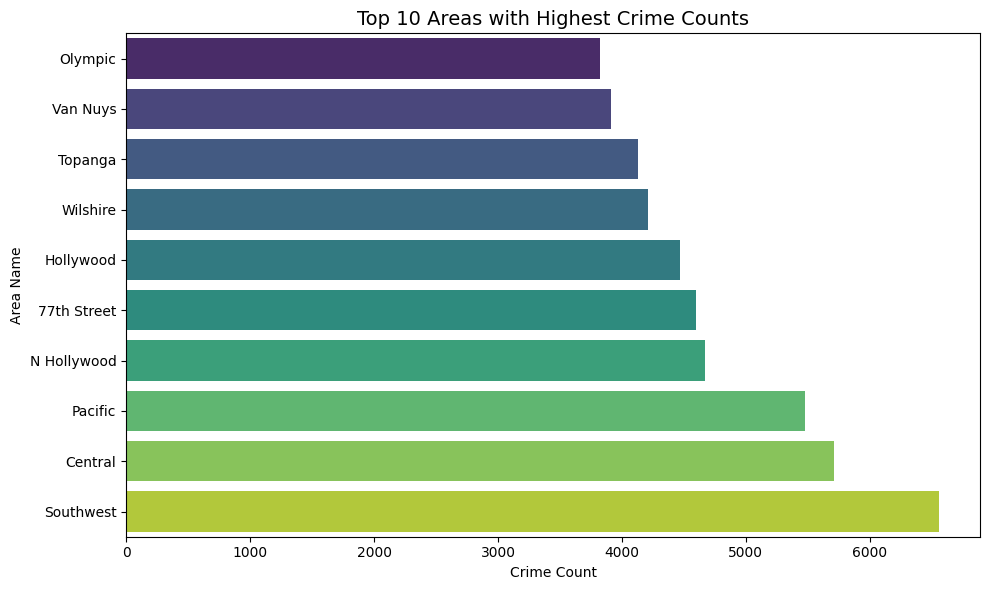

'\nThe bar chart above shows the top 10 areas in Los Angeles with the highest crime counts in 2024.\nThis visualization helps identify hotspots for crime, which can inform resource allocation and prevention strategies.\nSouthwest Los Angeles, Central Los Angeles, and Pacific Los Angeles are among the areas with the highest crime rates in 2024.'

In [ ]:
crime_counts = (
    data.groupby("area_name")
    .size()
    .reset_index(name="crime_count")
    .sort_values("crime_count", ascending=False)
)

# Top 10 areas
top_10_areas = crime_counts.head(10)

# Sort for readability
top_10_sorted = top_10_areas.sort_values('crime_count', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_sorted,
    y='area_name',
    x='crime_count',
    palette='viridis'
)

plt.title("Top 10 Areas with Highest Crime Counts", fontsize=14)
plt.xlabel("Crime Count")
plt.ylabel("Area Name")
plt.tight_layout()
plt.show()

'''
The bar chart above shows the top 10 areas in Los Angeles with the highest crime counts in 2024.
This visualization helps identify hotspots for crime, which can inform resource allocation and prevention strategies.
Southwest Los Angeles, Central Los Angeles, and Pacific Los Angeles are among the areas with the highest crime rates in 2024.'''

============================================================
 CHI-SQUARE TEST: CRIME SERIOUSNESS × AREA
============================================================

In [ ]:
if "part_1_2" in data.columns:
    contingency = pd.crosstab(data['area_name'], data['part_1_2'])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print("\nChi-Squared Results:")
    print(f"Chi2 = {chi2}, p = {p}, dof = {dof}")

'''
The chi-square test indicates a significant association between area and crime seriousness.
This suggests that certain areas may experience different levels of serious vs non-serious crimes.
'''


Chi-Squared Results:
Chi2 = 1643.9404471333796, p = 0.0, dof = 20


'\nThe chi-square test indicates a significant association between area and crime seriousness.\nThis suggests that certain areas may experience different levels of serious vs non-serious crimes.\n'

============================================================
 MODELING: CRIME INTENSITY EXPLAINED BY AREA FEATURES
============================================================
 FEATURE ENGINEERING — AREA-LEVEL AGGREGATES


Model Performance:
RMSE: 1299.9434777299614
R²: 0.14352873237893993

Feature Importances:
              feature  importance
2  pct_female_victims    0.411030
4            mean_lon    0.175461
6    unique_locations    0.131815
3            mean_lat    0.089813
5  unique_crime_types    0.081023
1    pct_male_victims    0.066032
0     mean_victim_age    0.044825


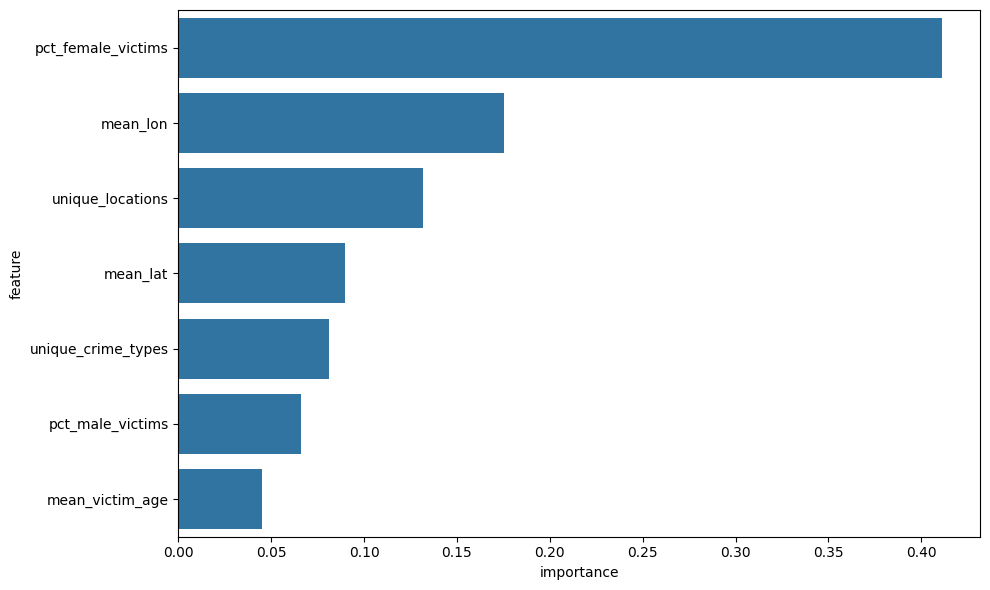

'\nThe Ramdomn Forest model performance indicates that area features moderately explain crime intensity variations.\nHowever, the low R² suggests the model is not highly predictive, likely due to unmeasured factors influencing crime rates.\nBelow, we try the Negative Binomial Regression model to see if it improves explanatory power.\n'

In [ ]:
area_df = (
    data.groupby("area_name")
        .agg(
            crime_count=("dr_no","count"),
            mean_victim_age=("vict_age","mean"),
            pct_male_victims=("vict_sex",lambda x:(x=="M").mean()),
            pct_female_victims=("vict_sex",lambda x:(x=="F").mean()),
            mean_lat=("lat","mean"),
            mean_lon=("lon","mean"),
            unique_crime_types=("crm_cd_desc","nunique"),
            unique_locations=("location","nunique")
        )
        .dropna()
        .reset_index()
)

# RANDOM FOREST REGRESSOR

X = area_df.drop(columns=["crime_count", "area_name"])
y = area_df["crime_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\nModel Performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature Importances:")
print(feat_imp)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="importance", y="feature")
plt.tight_layout()
plt.show()

'''
The Ramdomn Forest model performance indicates that area features moderately explain crime intensity variations.
However, the low R² suggests the model is not highly predictive, likely due to unmeasured factors influencing crime rates.
Below, we try the Negative Binomial Regression model to see if it improves explanatory power.
'''

 NEGATIVE BINOMIAL REGRESSION

C:\Users\Ebrima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



Negative Binomial Regression Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:            crime_count   No. Observations:                   21
Model:                            GLM   Df Residuals:                       13
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -194.16
Date:                Thu, 11 Dec 2025   Deviance:                      0.48674
Time:                        12:29:50   Pearson chi2:                    0.472
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04569
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

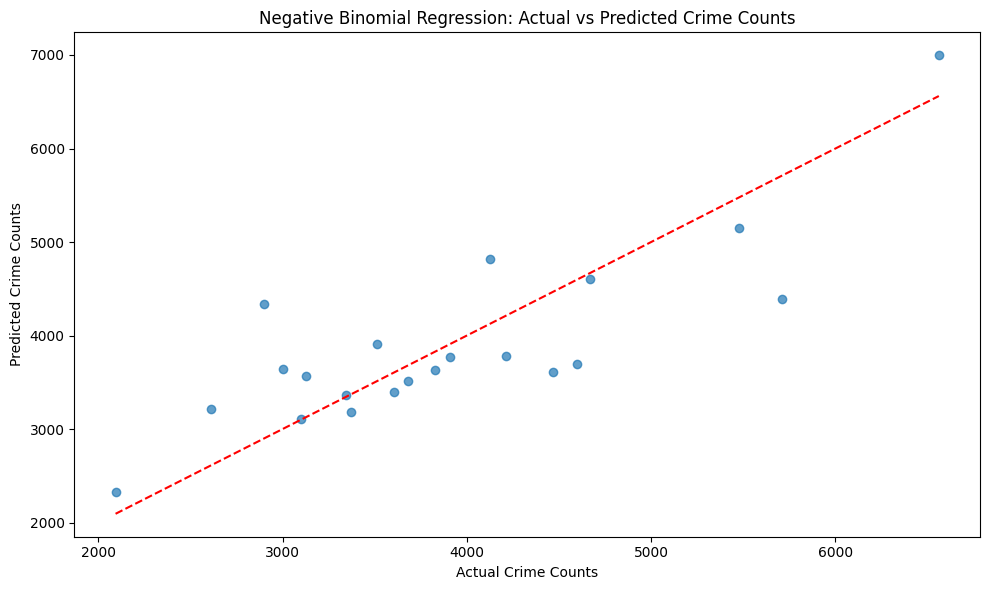

'\nThe Negative Binomial Regression model provides interpretable rate ratios for each predictor.\nThe pseudo R² indicates a modest explanatory power, suggesting that while area features contribute to crime intensity, \nother unmeasured factors likely play significant roles.\nThough negative binomial perform better, both models highlight the complexity of crime dynamics and the need for more comprehensive data to improve predictions.\n'

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
area_df_nb = area_df.copy()
area_df_nb = area_df_nb.dropna()
formula = "crime_count ~ mean_victim_age + pct_male_victims + pct_female_victims + mean_lat + mean_lon + unique_crime_types + unique_locations"
nb_model = smf.glm(formula=formula, data=area_df_nb, family=sm.families.NegativeBinomial()).fit()
print("\nNegative Binomial Regression Summary:")
print(nb_model.summary())

#Rate Ratio, interpretable effects, R squared, AIC
print("\nNegative Binomial Regression Rate Ratios:")
rate_ratios = np.exp(nb_model.params)
print(rate_ratios)
print("\nNegative Binomial Regression AIC:", nb_model.aic)
pseudo_r2 = 1 - nb_model.deviance / nb_model.null_deviance
print("Negative Binomial Regression Pseudo R²:", pseudo_r2)

#Plot negative binomial regression results
predicted_counts = nb_model.predict(area_df_nb)
plt.figure(figsize=(10,6))
plt.scatter(area_df_nb['crime_count'], predicted_counts, alpha=0.7) 
plt.plot([area_df_nb['crime_count'].min(), area_df_nb['crime_count'].max()],
         [area_df_nb['crime_count'].min(), area_df_nb['crime_count'].max()],
         color='red', linestyle='--')
plt.xlabel("Actual Crime Counts")
plt.ylabel("Predicted Crime Counts")
plt.title("Negative Binomial Regression: Actual vs Predicted Crime Counts")
plt.tight_layout()
plt.show()

'''
The Negative Binomial Regression model provides interpretable rate ratios for each predictor.
The pseudo R² indicates a modest explanatory power, suggesting that while area features contribute to crime intensity, 
other unmeasured factors likely play significant roles.
Though negative binomial perform better, both models highlight the complexity of crime dynamics and the need for more comprehensive data to improve predictions.
'''

============================================================
 13. SMART QUESTION 3 — TEMPORAL PATTERNS
============================================================
SMART Question:
Do crime incidents differ significantly between weekdays and weekends in Los Angeles during 2024?
If differences exist, are they mainly about how much crime happens,
or when during the day crime occurs?

In [ ]:
df_time = data.copy()

# Keep only crimes from 2024
df_time = df_time[df_time["date_occ"].dt.year == 2024]
print("Rows in 2024 subset:", df_time.shape[0])
#because the date_rptd contains crimes occurred in previous years but reported in 2024

Rows in 2024 subset: 76788


============================================================
 Clean TIME_OCC properly
============================================================
We must ensure time_occ is valid HHMM format.
Remove missing times and times with invalid minutes (>= 60).
 Convert to numeric

In [ ]:
df_time["time_occ"] = pd.to_numeric(df_time["time_occ"], errors="coerce")

# Remove rows with missing times
df_time = df_time.dropna(subset=["time_occ"])

# Remove invalid minutes (HH**MM** where MM >= 60)
valid_time = (df_time["time_occ"] % 100) < 60
df_time = df_time[valid_time]

# Extract hour (0–23)
df_time["hour"] = (df_time["time_occ"] // 100).astype(int)

print("Rows after cleaning time:", df_time.shape[0])

Rows after cleaning time: 76788


============================================================
 FEATURE ENGINEERING — TEMPORAL VARIABLES
============================================================
 Day-of-week features

In [ ]:
df_time["day_num"] = df_time["date_occ"].dt.dayofweek
df_time["day_of_week"] = df_time["date_occ"].dt.day_name()
df_time["is_weekend"] = df_time["day_num"].isin([5,6]).astype(int)

# Time-of-day category
def time_category(h):
    if 0 <= h <= 5: return "Night"
    if 6 <= h <= 11: return "Morning"
    if 12 <= h <= 17: return "Afternoon"
    return "Evening"

df_time["time_of_day"] = df_time["hour"].apply(time_category)

============================================================
 EDA — CRIME BY DAY OF WEEK
============================================================

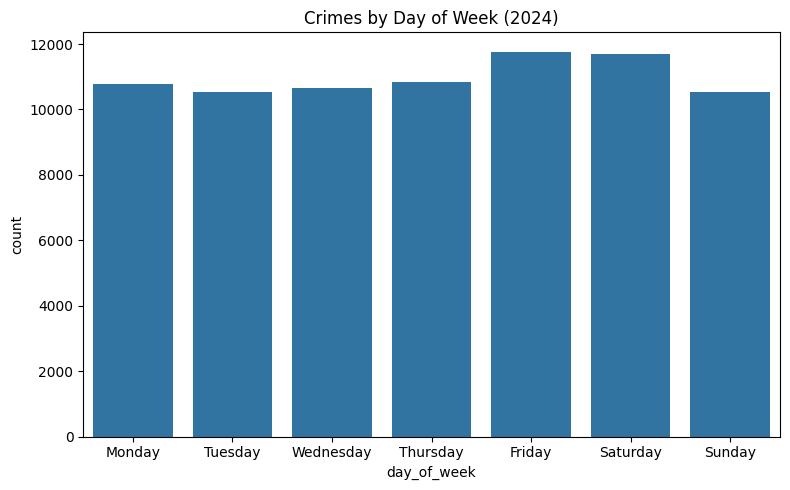

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_time,
    x="day_of_week",
    order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)
plt.title("Crimes by Day of Week (2024)")
plt.tight_layout()
plt.show()

============================================================
 STATISTICAL TEST — DAILY CRIME LEVELS (WELCH'S T-TEST)
============================================================
Does the daily number of crimes differ between weekdays and weekends?

In [ ]:
from scipy import stats

# Daily crime counts
daily_counts = df_time.groupby(df_time["date_occ"].dt.date).size()

weekday_daily = daily_counts[pd.to_datetime(daily_counts.index).weekday < 5]
weekend_daily = daily_counts[pd.to_datetime(daily_counts.index).weekday >= 5]

t_stat, p_val = stats.ttest_ind(
    weekday_daily, weekend_daily, equal_var=False
)

print("\nWelch t-test (Daily Crime Levels):")
print("t-statistic:", t_stat)
print("p-value:", p_val)

# Interpretation
'''
Daily crime levels do NOT differ significantly between weekdays and weekends.
'''


Welch t-test (Daily Crime Levels):
t-statistic: -0.32783352457830756
p-value: 0.7434040555698602


'\nDaily crime levels do NOT differ significantly between weekdays and weekends.\n'

============================================================
 EDA — HOURLY CRIME PATTERNS
============================================================

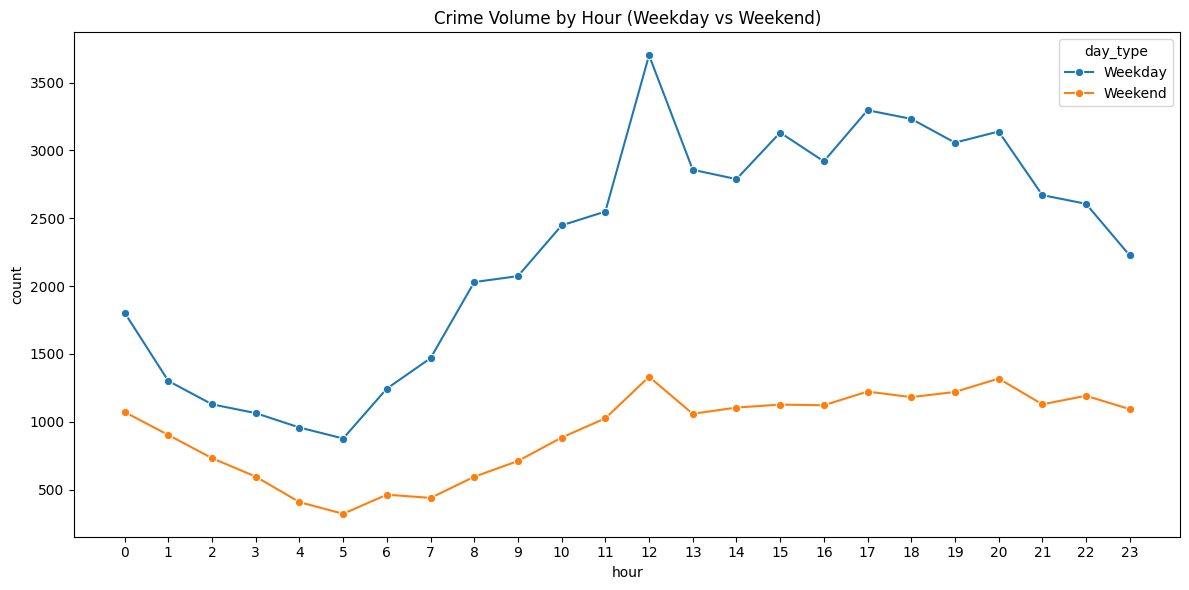

In [ ]:
hourly_counts = df_time.groupby(["hour","is_weekend"]).size().reset_index(name="count")
hourly_counts["day_type"] = hourly_counts["is_weekend"].map({0:"Weekday",1:"Weekend"})

plt.figure(figsize=(12,6))
sns.lineplot(
    data=hourly_counts,
    x="hour", y="count",
    hue="day_type", marker="o"
)
plt.title("Crime Volume by Hour (Weekday vs Weekend)")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

============================================================
 STATISTICAL TEST — HOURLY CRIME LEVELS (WELCH'S T-TEST)
============================================================

In [ ]:
hourly_daily = df_time.groupby(
    [df_time["date_occ"].dt.date, "hour"]
).size().reset_index(name="count")

weekday_hour = hourly_daily[pd.to_datetime(hourly_daily["date_occ"]).dt.weekday < 5]["count"]
weekend_hour = hourly_daily[pd.to_datetime(hourly_daily["date_occ"]).dt.weekday >= 5]["count"]

t_stat2, p_val2 = stats.ttest_ind(
    weekday_hour, weekend_hour, equal_var=False
)

print("\nWelch t-test (Hourly Crime Levels):")
print("t-statistic:", t_stat2)
print("p-value:", p_val2)

# Interpretation
'''
Hourly averages also do NOT differ significantly between weekdays and weekends.
'''


Welch t-test (Hourly Crime Levels):
t-statistic: -0.9789121898762273
p-value: 0.3276749980744724


'\nHourly averages also do NOT differ significantly between weekdays and weekends.\n'

============================================================
 EDA — TIME-OF-DAY CATEGORY DISTRIBUTIONS
============================================================

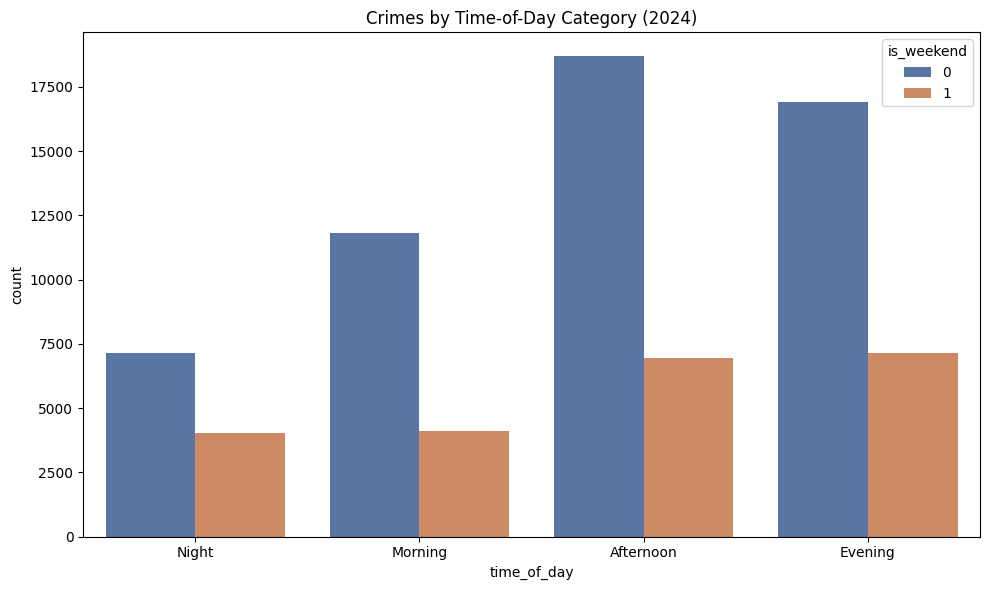

In [ ]:
order_tod = ["Night","Morning","Afternoon","Evening"]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_time,
    x="time_of_day",
    order=order_tod,
    hue="is_weekend",
    palette={0:"#4c72b0", 1:"#dd8452"}
)
plt.title("Crimes by Time-of-Day Category (2024)")
plt.tight_layout()
plt.show()

============================================================
 STATISTICAL TEST — TIME-OF-DAY × WEEKEND (CHI-SQUARE)
============================================================

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_time["time_of_day"], df_time["is_weekend"])
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-Square Test (Time-of-Day × Weekend):")
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# Interpretation
'''
There IS a statistically significant difference in crime timing across the day
between weekdays and weekends.
'''


Chi-Square Test (Time-of-Day × Weekend):
Chi-square: 399.4536388083641
p-value: 2.907373748784058e-86
Degrees of freedom: 3


'\nThere IS a statistically significant difference in crime timing across the day\nbetween weekdays and weekends.\n'

============================================================
 Summary of SMART Question 3 Findings
============================================================
Daily crime levels: NOT significantly different
Hourly averages: NOT significantly different
Time-of-day distribution: SIGNIFICANTLY different
Conclusion
The difference between weekday and weekend crime is not about volume,
but *when during the day* the crimes occur.
============================================================

============================================================

In [ ]:
print("\nALL ANALYSIS COMPLETE.")

#END OF PROJECT WORK 
#############################################################
# ============================================================
# THANK YOU FOR REVIEWING OUR CODE!


ALL ANALYSIS COMPLETE.
